# 04 — Task 2.2: NRC Lexicon Classifier
Two experiments on the IMDB test set:
- **Exp 1**: NRC lexicon, no negation handling
- **Exp 2**: NRC lexicon, with negation handling

In [3]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import nltk
from tqdm import tqdm

def nltk_ensure(resource, path):
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource, quiet=True)

nltk_ensure('punkt',     'tokenizers/punkt')
nltk_ensure('punkt_tab', 'tokenizers/punkt_tab')
nltk_ensure('wordnet',   'corpora/wordnet')
nltk_ensure('stopwords', 'corpora/stopwords')

from src.utils import load_data, load_nrc_lexicon, evaluate_predictions, save_results, _NEGATION_WORDS, _NEGATION_WINDOW

test_texts, test_labels = load_data('test')
lexicon = load_nrc_lexicon()
print(f'Test set : {len(test_texts):,} reviews')
print(f'NRC words: {len(lexicon):,}')

Test set : 2,000 reviews
NRC words: 6,468


## Helper — tokenise + lemmatise

In [4]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def tokenise(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(t) for t in tokens if t.isalpha()]

def tokenise_with_negation(text):
    """Returns tokens with _NEG suffix applied after negation words."""
    tokens = tokenise(text)
    result = []
    neg_counter = 0
    for token in tokens:
        if token in _NEGATION_WORDS:
            result.append(token)
            neg_counter = _NEGATION_WINDOW
        elif neg_counter > 0:
            result.append(token + '_NEG')
            neg_counter -= 1
        else:
            result.append(token)
    return result

## NRC scoring helper

In [5]:
def nrc_classify(tokens, lexicon, handle_negation=False):
    """
    Score a token list against the NRC lexicon.
    With handle_negation=True, tokens ending in _NEG flip polarity.
    Returns 'pos' or 'neg'.
    """
    pos_score = 0
    neg_score = 0
    for token in tokens:
        negated = handle_negation and token.endswith('_NEG')
        word = token[:-4] if negated else token
        if word in lexicon:
            p = lexicon[word]['positive']
            n = lexicon[word]['negative']
            if negated:
                p, n = n, p
            pos_score += p
            neg_score += n
    return 'pos' if pos_score > neg_score else 'neg'


def predict_nrc(texts, lexicon, use_negation=False):
    preds = []
    tok_fn = tokenise_with_negation if use_negation else tokenise
    for text in tqdm(texts, desc=f'NRC (negation={use_negation})'):
        tokens = tok_fn(text)
        preds.append(nrc_classify(tokens, lexicon, handle_negation=use_negation))
    return preds

## Experiment 1 — No negation

In [6]:
preds_no_neg = predict_nrc(test_texts, lexicon, use_negation=False)
metrics_no_neg = evaluate_predictions(test_labels, preds_no_neg)
print('NRC (no negation):', metrics_no_neg)
save_results('2.2', 'NRC Lexicon', metrics_no_neg,
             preprocessing='lowercase, lemmatization, no negation',
             notes='tie-break → neg')

NRC (negation=False): 100%|██████████| 2000/2000 [00:01<00:00, 1036.78it/s]

NRC (no negation): {'accuracy': 0.646, 'precision': 0.616, 'recall': 0.816, 'f1': 0.702}
Saved: [2.2] NRC Lexicon — acc=0.646 f1=0.702


## Experiment 2 — With negation handling

In [7]:
preds_neg = predict_nrc(test_texts, lexicon, use_negation=True)
metrics_neg = evaluate_predictions(test_labels, preds_neg)
print('NRC (with negation):', metrics_neg)
save_results('2.2', 'NRC Lexicon + Negation', metrics_neg,
             preprocessing='lowercase, lemmatization, negation window=3',
             notes='polarity flipped for tokens within 3 positions after negation word')

NRC (negation=True): 100%|██████████| 2000/2000 [00:00<00:00, 2159.60it/s]

NRC (with negation): {'accuracy': 0.655, 'precision': 0.6254, 'recall': 0.8102, 'f1': 0.7059}
Saved: [2.2] NRC Lexicon + Negation — acc=0.655 f1=0.7059


## Comparison

,accuracy,precision,recall,f1
Approach,,,,
NRC (no negation),0.646,0.6160,0.8160,0.7020
NRC + negation,0.655,0.6254,0.8102,0.7059


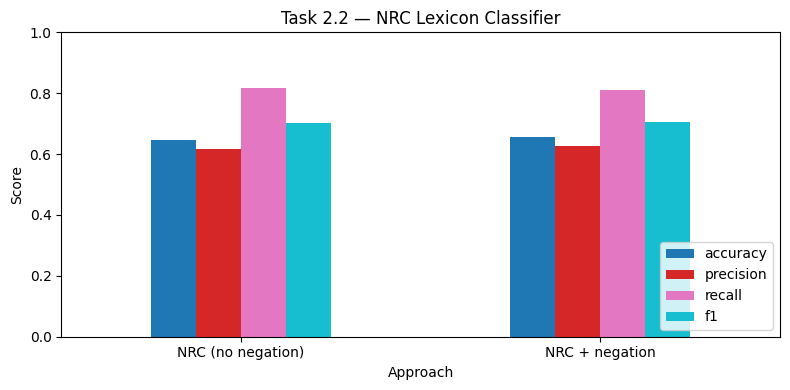

In [8]:
import matplotlib.pyplot as plt
from IPython.display import display

comp = pd.DataFrame([
    {'Approach': 'NRC (no negation)', **metrics_no_neg},
    {'Approach': 'NRC + negation',    **metrics_neg},
])
display(comp.set_index('Approach'))

ax = comp.set_index('Approach')[['accuracy','precision','recall','f1']].plot(
    kind='bar', figsize=(8, 4), rot=0, colormap='tab10')
ax.set_ylim(0, 1)
ax.set_title('Task 2.2 — NRC Lexicon Classifier')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/fig_nrc_lexicon.png', dpi=150, bbox_inches='tight')
plt.show()

## Coverage analysis

In [9]:
coverage = []
for text in test_texts[:1000]:
    tokens = tokenise(text)
    found = sum(1 for t in tokens if t in lexicon)
    coverage.append(found / len(tokens) if tokens else 0)

print(f'Mean lexicon coverage per review: {sum(coverage)/len(coverage):.1%}')

Mean lexicon coverage per review: 12.1%
